

# Rejecting bad data spans and breaks

This tutorial covers:

- manual marking of bad spans of data,
- automated rejection of data spans based on signal amplitude, and
- automated detection of breaks during an experiment.

We begin as always by importing the necessary Python modules and loading some
`example data <sample-dataset>`; to save memory we'll use a pre-filtered
and downsampled version of the example data, and we'll also load an events
array to use when converting the continuous data to epochs:


In [1]:
# Authors: The MNE-Python contributors.
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [2]:
import os

import numpy as np

import mne

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(
    sample_data_folder, "MEG", "sample", "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file, verbose=False)
events_file = os.path.join(
    sample_data_folder, "MEG", "sample", "sample_audvis_filt-0-40_raw-eve.fif"
)
events = mne.read_events(events_file)

## Annotating bad spans of data

The tutorial `tut-events-vs-annotations` describes how
:class:`~mne.Annotations` can be read from embedded events in the raw
recording file, and `tut-annotate-raw` describes in detail how to
interactively annotate a :class:`~mne.io.Raw` data object. Here, we focus on
best practices for annotating *bad* data spans so that they will be excluded
from your analysis pipeline.


### The ``reject_by_annotation`` parameter

In the interactive ``raw.plot()`` window, the annotation controls can be
opened by pressing :kbd:`a`. Here, new annotation labels can be created or
existing annotation labels can be selected for use.



In [3]:
fig = raw.plot()
fig.fake_keypress("a")  # Simulates user pressing 'a' on the keyboard.

Using qt as 2D backend.


QStandardPaths: wrong permissions on runtime directory /run/user/1000/, 0755 instead of 0700


You can see that you need to add a description first to start with
marking spans (Push the button "Add Description" and enter the description).
You can use any description you like, but annotations marking spans that
should be excluded from the analysis pipeline should all begin with "BAD" or
"bad" (e.g., "bad_cough", "bad-eyes-closed", "bad door slamming", etc). When
this practice is followed, many processing steps in MNE-Python will
automatically exclude the "bad"-labelled spans of data; this behavior is
controlled by a parameter ``reject_by_annotation`` that can be found in many
MNE-Python functions or class constructors, including:

- creation of epoched data from continuous data (:class:`mne.Epochs`)
- many methods of the independent components analysis class
  (:class:`mne.preprocessing.ICA`)
- functions for finding heartbeat and blink artifacts
  (:func:`~mne.preprocessing.find_ecg_events`,
  :func:`~mne.preprocessing.find_eog_events`)
- covariance computations (:func:`mne.compute_raw_covariance`)
- power spectral density computation (:meth:`mne.io.Raw.compute_psd`)

For example, when creating epochs from continuous data, if
``reject_by_annotation=True`` the :class:`~mne.Epochs` constructor will drop
any epoch that partially or fully overlaps with an annotated span that begins
with "bad".


### Generating annotations programmatically

The `tut-artifact-overview` tutorial introduced the artifact detection
functions :func:`~mne.preprocessing.find_eog_events` and
:func:`~mne.preprocessing.find_ecg_events` (although that tutorial mostly
relied on their higher-level wrappers
:func:`~mne.preprocessing.create_eog_epochs` and
:func:`~mne.preprocessing.create_ecg_epochs`). Here, for demonstration
purposes, we make use of the lower-level artifact detection function to get
an events array telling us where the blinks are, then automatically add
"bad_blink" annotations around them (this is not necessary when using
:func:`~mne.preprocessing.create_eog_epochs`, it is done here just to show
how annotations are added non-interactively). We'll start the annotations
250 ms before the blink and end them 250 ms after it:



In [4]:
eog_events = mne.preprocessing.find_eog_events(raw)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

Using EOG channel: EOG 061
EOG channel index for this subject is: [375]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG 061 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1502 samples (10.003 s)

Now detecting blinks and generating corresponding events
Found 46 significant peaks
Number of EOG events detected: 46


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>

Now we can confirm that the annotations are centered on the EOG events. Since
blinks are usually easiest to see in the EEG channels, we'll only plot EEG
here:



In [5]:
eeg_picks = mne.pick_types(raw.info, meg=False, eeg=True)
raw.plot(events=eog_events, order=eeg_picks)

See the section `tut-section-programmatic-annotations` for more details
on creating annotations programmatically.

### Detecting and annotating breaks
Another useful function, albeit not related to artifact detection *per se*,
is `mne.preprocessing.annotate_break`: It will generate annotations for
segments of the data where no existing annotations (or, alternatively:
events) can be found. It can therefore be used to automatically detect and
mark breaks, e.g. between experimental blocks, when recording continued.

For the sake of this example, let's assume an experiment consisting of two
blocks, the first one stretching from 30 to 90, and the second from 120 to
180 seconds. We'll mark these blocks by annotations, and then use
`mne.preprocessing.annotate_break` to detect and annotate any breaks.

<div class="alert alert-info"><h4>Note</h4><p>We need to take ``raw.first_time`` into account, otherwise the
          onsets will be incorrect!</p></div>



In [6]:
onsets = [raw.first_time + 30, raw.first_time + 180]
durations = [60, 60]
descriptions = ["block_1", "block_2"]

block_annots = mne.Annotations(
    onset=onsets,
    duration=durations,
    description=descriptions,
    orig_time=raw.info["meas_date"],
)
raw.set_annotations(raw.annotations + block_annots)  # add to existing
raw.plot()

Now detect break periods. We can control how far the break annotations shall
expand toward both ends of each break.



In [7]:
break_annots = mne.preprocessing.annotate_break(
    raw=raw,
    min_break_duration=20,  # consider segments of at least 20 s duration
    t_start_after_previous=5,  # start annotation 5 s after end of previous one
    t_stop_before_next=2,  # stop annotation 2 s before beginning of next one
)

raw.set_annotations(raw.annotations + break_annots)  # add to existing
raw.plot()

Ignoring annotations with descriptions starting with: bad, edge

Detected 3 break periods of >= 20 s duration:
    0.0 – 28.0 s [28.0 s]
    95.0 – 178.0 s [83.0 s]
    245.0 – 277.7 s [32.7 s]
In total, 51.7% of the data (143.7 s) have been marked as a break.



You can see that 3 segments have been annotated as ``BAD_break``:

- the first one starting with the beginning of the recording and ending 2
  seconds before the beginning of block 1 (due to ``t_stop_before_next=2``),
- the second one starting 5 seconds after block 1 has ended, and ending 2
  seconds before the beginning of block 2 (``t_start_after_previous=5``,
  ``t_stop_before_next=2``),
- and the last one starting 5 seconds after block 2 has ended
  (``t_start_after_previous=5``) and continuing until the end of the
  recording.

You can also see that only the ``block_1`` and ``block_2`` annotations
were considered in the detection of the break periods – the EOG annotations
were simply ignored. This is because, by default,
`~mne.preprocessing.annotate_break` ignores all annotations starting with
``'bad'``. You can control this behavior via the ``ignore`` parameter.

It is also possible to perform break period detection based on an array
of events: simply pass the array via the ``events`` parameter. Existing
annotations in the raw data will be ignored in this case:



In [8]:
# only keep some button press events (code 32) for this demonstration
events_subset = events[events[:, -1] == 32]
# drop the first and last few events
events_subset = events_subset[3:-3]

break_annots = mne.preprocessing.annotate_break(
    raw=raw,
    events=events_subset,  # passing events will ignore existing annotations
    min_break_duration=25,  # pick a longer break duration this time
)

# replace existing annotations (otherwise it becomes difficult to see any
# effects in the plot!)
raw.set_annotations(break_annots)
raw.plot(events=events_subset)


Detected 2 break periods of >= 25 s duration:
    0.0 – 51.4 s [51.4 s]
    185.6 – 277.7 s [92.1 s]
In total, 51.7% of the data (143.5 s) have been marked as a break.




## Rejecting Epochs based on peak-to-peak channel amplitude

Besides "bad" annotations, the :class:`mne.Epochs` class constructor has
another means of rejecting epochs, based on signal amplitude thresholds for
each channel type. In the `overview tutorial
<tut-section-overview-epoching>` we saw an example of this: setting maximum
acceptable peak-to-peak amplitudes for each channel type in an epoch, using
the ``reject`` parameter. There is also a related parameter, ``flat``, that
can be used to set *minimum* acceptable peak-to-peak amplitudes for each
channel type in an epoch:



In [9]:
reject_criteria = dict(
    mag=3000e-15,  # 3000 fT
    grad=3000e-13,  # 3000 fT/cm
    eeg=100e-6,  # 100 µV
    eog=200e-6,
)  # 200 µV

flat_criteria = dict(mag=1e-15, grad=1e-13, eeg=1e-6)  # 1 fT  # 1 fT/cm  # 1 µV

The values that are appropriate are dataset- and hardware-dependent, so some
trial-and-error may be necessary to find the correct balance between data
quality and loss of power due to too many dropped epochs. Here, we've set the
rejection criteria to be fairly stringent, for illustration purposes.

Two additional parameters, ``reject_tmin`` and ``reject_tmax``, are used to
set the temporal window in which to calculate peak-to-peak amplitude for the
purposes of epoch rejection. These default to the same ``tmin`` and ``tmax``
of the entire epoch. As one example, if you wanted to only apply the
rejection thresholds to the portion of the epoch that occurs *before* the
event marker around which the epoch is created, you could set
``reject_tmax=0``. A summary of the causes of rejected epochs can be
generated with the :meth:`~mne.Epochs.plot_drop_log` method:



Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Loading data for 319 events and 106 original time points ...
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 003', 'EEG 007']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 007']
    Rejecting  epoch based on EEG : ['EEG 003']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003']
8 bad epochs dropped


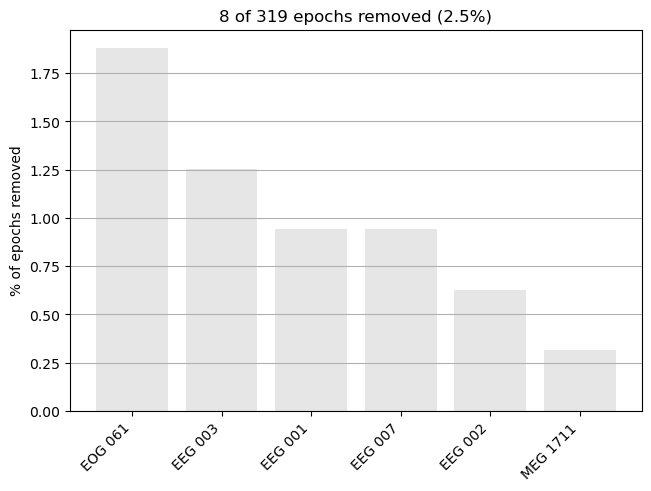

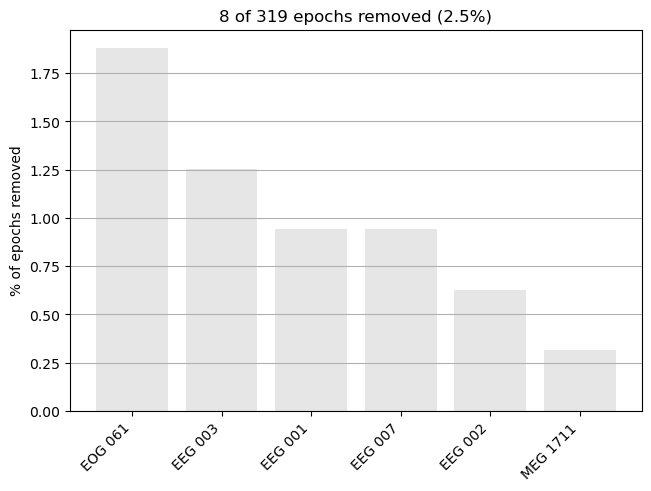

In [10]:
raw.set_annotations(blink_annot)  # restore the EOG annotations
epochs = mne.Epochs(
    raw,
    events,
    tmin=-0.2,
    tmax=0.5,
    reject_tmax=0,
    reject=reject_criteria,
    flat=flat_criteria,
    reject_by_annotation=False,
    preload=True,
)
epochs.plot_drop_log()

Notice that we've passed ``reject_by_annotation=False`` above, in order to
isolate the effects of the rejection thresholds. If we re-run the epoching
with ``reject_by_annotation=True`` (the default) we see that the rejections
due to EEG and EOG channels have disappeared (suggesting that those channel
fluctuations were probably blink-related, and were subsumed by rejections
based on the "bad blink" label).



Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Loading data for 319 events and 106 original time points ...
    Rejecting  epoch based on MAG : ['MEG 1711']
39 bad epochs dropped


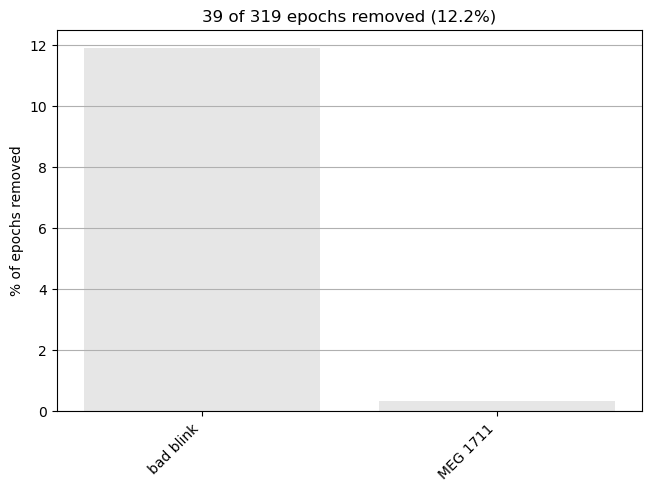

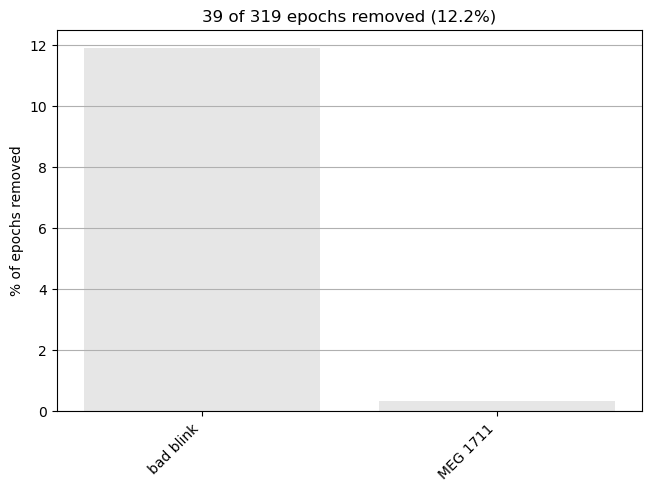

In [11]:
epochs = mne.Epochs(
    raw,
    events,
    tmin=-0.2,
    tmax=0.5,
    reject_tmax=0,
    reject=reject_criteria,
    flat=flat_criteria,
    preload=True,
)
epochs.plot_drop_log()

More importantly, note that *many* more epochs are rejected (~12.2% instead
of ~2.5%) when rejecting based on the blink labels, underscoring why it is
usually desirable to repair artifacts rather than exclude them.

The :meth:`~mne.Epochs.plot_drop_log` method is a visualization of an
:class:`~mne.Epochs` attribute, namely ``epochs.drop_log``, which stores
empty lists for retained epochs and lists of strings for dropped epochs, with
the strings indicating the reason(s) why the epoch was dropped. For example:



In [12]:
print(epochs.drop_log)

((np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (), (), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (np.str_('bad blink'),), (), (np.str_('bad blink'),), (np.str_('bad blink'),), (), (), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ('MEG 1711',), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('bad blink'),), (), (np.str_('bad blink'),), (np.str_('bad blink'),), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.s

Finally, it should be noted that "dropped" epochs are not necessarily deleted
from the :class:`~mne.Epochs` object right away. Above, we forced the
dropping to happen when we created the :class:`~mne.Epochs` object by using
the ``preload=True`` parameter. If we had not done that, the
:class:`~mne.Epochs` object would have been `memory-mapped`_ (not loaded into
RAM), in which case the criteria for dropping epochs are stored, and the
actual dropping happens when the :class:`~mne.Epochs` data are finally loaded
and used. There are several ways this can get triggered, such as:

- explicitly loading the data into RAM with the :meth:`~mne.Epochs.load_data`
  method
- plotting the data (:meth:`~mne.Epochs.plot`,
  :meth:`~mne.Epochs.plot_image`, etc)
- using the :meth:`~mne.Epochs.average` method to create an
  :class:`~mne.Evoked` object

You can also trigger dropping with the :meth:`~mne.Epochs.drop_bad` method;
if ``reject`` and/or ``flat`` criteria have already been provided to the
epochs constructor, :meth:`~mne.Epochs.drop_bad` can be used without
arguments to simply delete the epochs already marked for removal (if the
epochs have already been dropped, nothing further will happen):



In [13]:
epochs.drop_bad()

Alternatively, if rejection thresholds were not originally given to the
:class:`~mne.Epochs` constructor, they can be passed to
:meth:`~mne.Epochs.drop_bad` later instead; this can also be a way of
imposing progressively more stringent rejection criteria:



In [14]:
stronger_reject_criteria = dict(
    mag=2000e-15,  # 2000 fT
    grad=2000e-13,  # 2000 fT/cm
    eeg=100e-6,  # 100 µV
    eog=100e-6,
)  # 100 µV

epochs.drop_bad(reject=stronger_reject_criteria)
print(epochs.drop_log)

    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1411', 'MEG 1421', 'MEG 1431', 'MEG 1541']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1411', 'MEG 1421', 'MEG 1431', 'MEG 1441', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0141', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1421', 'MEG 1431']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1411', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rejecting  epoch based on MAG : ['MEG 0111', 'MEG 0141', 'MEG 1411', 'MEG 1421', 'MEG 1431', 'MEG 1541', 'MEG 2621']
    Rej


## Rejecting Epochs using callables (functions)
Sometimes it is useful to reject epochs based criteria other than
peak-to-peak amplitudes. For example, we might want to reject epochs
based on the maximum or minimum amplitude of a channel.
In this case, the `mne.Epochs.drop_bad` function also accepts
callables (functions) in the ``reject`` and ``flat`` parameters. This
allows us to define functions to reject epochs based on our desired criteria.

Let's begin by generating Epoch data with large artifacts in one eeg channel
in order to demonstrate the versatility of this approach.



In [15]:
raw.crop(0, 5)
raw.del_proj()
chans = raw.info["ch_names"][-5:-1]
raw.pick(chans)
data = raw.get_data()

new_data = data
new_data[0, 180:200] *= 1e3
new_data[0, 460:580] += 1e-3
edit_raw = mne.io.RawArray(new_data, raw.info)

# Create fixed length epochs of 1 second
events = mne.make_fixed_length_events(edit_raw, id=1, duration=1.0, start=0)
epochs = mne.Epochs(edit_raw, events, tmin=0, tmax=1, baseline=None)
epochs.plot(scalings=dict(eeg=50e-5))

Creating RawArray with float64 data, n_channels=4, n_times=752
    Range : 0 ... 751 =      0.000 ...     5.002 secs
Ready.
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 5 events and 151 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 5 events and 151 original time points ...
Using data from preloaded Raw for 1 events and 151 original time points ...
Using data from preloaded Raw for 1 events and 151 original time points ...
Using data from preloaded Raw for 1 events and 151 original time points ...
Using data from preloaded Raw for 1 events and 151 original time points ...
Using data from preloaded Raw for 1 events and 151 original time points ...
Using data from preloaded Raw for 5 events and 151 original time points ...
Using data from preloaded Raw for 5 events and 151 original time points ...


As you can see, we have two large artifacts in the first channel. One large
spike in amplitude and one large increase in amplitude.



In [16]:
# Let's try to reject the epoch containing the spike in amplitude based on the
# maximum amplitude of the first channel. Please note that the callable in
# ``reject`` must return a (good, reason) tuple. Where the good must be bool
# and reason must be a str, list, or tuple where each entry is a str.

epochs = mne.Epochs(
    edit_raw,
    events,
    tmin=0,
    tmax=1,
    baseline=None,
    preload=True,
)

epochs.drop_bad(
    reject=dict(eeg=lambda x: ((np.max(x, axis=1) > 1e-2).any(), "max amp"))
)
epochs.plot(scalings=dict(eeg=50e-5))

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 5 events and 151 original time points ...
0 bad epochs dropped
1 bad epochs dropped


Here, the epoch containing the spike in amplitude was rejected for having a
maximum amplitude greater than 1e-2 Volts. Notice the use of the ``any()``
function to check if any of the channels exceeded the threshold. We could
have also used the ``all()`` function to check if all channels exceeded the
threshold.



In [17]:
# Next, let's try to reject the epoch containing the increase in amplitude
# using the median.

epochs = mne.Epochs(
    edit_raw,
    events,
    tmin=0,
    tmax=1,
    baseline=None,
    preload=True,
)

epochs.drop_bad(
    reject=dict(eeg=lambda x: ((np.median(x, axis=1) > 1e-4).any(), "median amp"))
)
epochs.plot(scalings=dict(eeg=50e-5))

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 5 events and 151 original time points ...
0 bad epochs dropped
1 bad epochs dropped


Finally, let's try to reject both epochs using a combination of the maximum
and median. We'll define a custom function and use boolean operators to
combine the two criteria.



In [ ]:
def reject_criteria(x):
    max_condition = np.max(x, axis=1) > 1e-2
    median_condition = np.median(x, axis=1) > 1e-4
    return ((max_condition.any() or median_condition.any()), ["max amp", "median amp"])


epochs = mne.Epochs(
    edit_raw,
    events,
    tmin=0,
    tmax=1,
    baseline=None,
    preload=True,
)

epochs.drop_bad(reject=dict(eeg=reject_criteria))
epochs.plot(events=True)

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 5 events and 151 original time points ...
0 bad epochs dropped
2 bad epochs dropped


Traceback (most recent call last):
  File "/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne_qt_browser/_pg_figure.py", line 5000, in _region_changed
    idx = self._get_onset_idx(region.old_onset)
  File "/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne_qt_browser/_pg_figure.py", line 4994, in _get_onset_idx
    idx = np.where(self.mne.inst.annotations.onset == onset)[0][0]
          ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
IndexError: index 0 is out of bounds for axis 0 with size 0
Traceback (most recent call last):
  File "/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne_qt_browser/_pg_figure.py", line 4673, in _yrange_changed
    trace.set_ch_idx(ch_idx)
    ~~~~~~~~~~~~~~~~^^^^^^^^
  File "/home/jshen/miniconda3/envs/Summer2025DL/lib/python3.13/site-packages/mne_qt_browser/_pg_figure.py", line 292, in wrapper
    result = method(*args, **kwargs)
  File "/home/jshen/miniconda3/envs/Summer2025D

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


Note that a complementary Python module, the `autoreject package`_, uses
machine learning to find optimal rejection criteria, and is designed to
integrate smoothly with MNE-Python workflows. This can be a considerable
time-saver when working with heterogeneous datasets.


.. LINKS


